In [59]:
# === 1) БАЗОВІ ПАКЕТИ ТА PYTORCH (CUDA 12.1) ===
%pip install --upgrade pip wheel setuptools

# PyTorch з підтримкою CUDA (під твій драйвер CUDA 12.9 сумісно з cu129)
%pip install --upgrade --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu129

# Корисні бібліотеки для ноутбука і нашого пайплайна
%pip install numpy pillow matplotlib opencv-python "albumentations>=2.0.0,<3.0" tqdm ipywidgets kaggle

# Спроба поставити готове колесо pycocotools
%pip install pycocotools
%pip install pandas matplotlib numpy seaborn jupyterlab notebook ipywidgets

# === 2) FALLBACK: якщо pycocotools не імпортується, збираємо з джерел ===
import importlib, sys, subprocess
try:
    importlib.import_module("pycocotools")
except Exception as e:
    print("pycocotools wheel недоступний для цієї версії Python. Ставимо з джерел…")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "cython"])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI"
    ])
try:
    import sys, subprocess
    subprocess.run(
        [sys.executable, "-m", "jupyter", "nbextension", "enable", "--py", "widgetsnbextension", "--sys-prefix"],
        check=False
    )
except Exception:
    pass




Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu129
  Using cached https://download.pytorch.org/whl/cu129/torch-2.8.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached https://download.pytorch.org/whl/cu129/torchvision-0.23.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu129/torchaudio-2.8.0%2Bcu129-cp311-cp311-win_amd64.whl.metadata (7.4 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.12.2-py3-none-any.whl.metadata (3.0 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached h

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'g:\\ml_labs\\venv311\\lib\\site-packages\\pil\\_imaging.cp311-win_amd64.pyd'
Check the permissions.



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [60]:
# === 3) ШВИДКА ПЕРЕВІРКА СЕРЕДОВИЩА ===
import torch, albumentations as A, numpy as np, cv2, PIL, matplotlib
print("torch:", torch.__version__, "| CUDA available?:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("torchvision:", __import__("torchvision").__version__)
print("albumentations:", A.__version__)
print("numpy:", np.__version__)
print("opencv:", cv2.__version__)
print("Pillow:", PIL.__version__)
print("matplotlib:", matplotlib.__version__)

torch: 2.8.0+cu129 | CUDA available?: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
torchvision: 0.23.0+cu129
albumentations: 2.0.8
numpy: 2.1.2
opencv: 4.12.0
Pillow: 11.0.0
matplotlib: 3.10.6


In [61]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # швидші kernels для стабільного розміру
print("Train on:", device)

Train on: cuda


In [62]:
import json
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter, defaultdict
import cv2
from tqdm.auto import tqdm
import pandas as pd

# Налаштування відображення
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [63]:
class COCODataset(Dataset):
    def __init__(self, root_dir, annotation_file, transform=None):
        """
        Args:
            root_dir (string): Directory with all the images
            annotation_file (string): Path to the COCO annotation file
            transform (callable, optional): Optional transform to be applied on images
        """
        self.root_dir = root_dir
        self.transform = transform
        
        # Load annotations
        with open(annotation_file, 'r') as f:
            self.coco_data = json.load(f)
        
        # Create dictionaries for quick lookup
        self.images = {img['id']: img for img in self.coco_data['images']}
        self.categories = {cat['id']: cat for cat in self.coco_data['categories']}
        
        # Group annotations by image_id for faster access
        self.image_annotations = defaultdict(list)
        for ann in self.coco_data['annotations']:
            self.image_annotations[ann['image_id']].append(ann)
        
        # List of all image ids to use for indexing
        self.image_ids = list(self.images.keys())
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        """Return image and its annotations"""
        image_id = self.image_ids[idx]
        img_info = self.images[image_id]
        file_name = img_info['file_name']
        
        # Load image
        img_path = os.path.join(self.root_dir, file_name)
        image = Image.open(img_path).convert('RGB')
        
        # Get annotations for this image
        annotations = self.image_annotations[image_id]
        
        # Extract bounding boxes, class labels, and segmentation masks
        boxes = []
        labels = []
        areas = []
        segmentations = []
        iscrowd = []
        
        for ann in annotations:
            boxes.append(ann['bbox'])  # [x, y, width, height]
            labels.append(ann['category_id'])
            areas.append(ann['area'])
            segmentations.append(ann['segmentation'])
            iscrowd.append(ann['iscrowd'])
        
        # Convert to tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        
        # Prepare target dict
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([image_id]),
            'area': areas,
            'iscrowd': iscrowd,
            'segmentations': segmentations
        }
        
        if self.transform is not None:
            image = self.transform(image)
        
        return image, target
    
    def get_img_info(self, idx):
        """Get image info by index"""
        image_id = self.image_ids[idx]
        return self.images[image_id]
    
    def get_category_name(self, label_idx: int) -> str:
        """label_idx: 1..K; повертає назву категорії."""
        coco_id = self.idx_to_cat_id[int(label_idx)]
        return self.categories[coco_id]['name']

    
    def get_category_info(self):
        """Get all category information"""
        return self.categories
    
    def num_classes(self) -> int:
        return len(self.cat_ids) + 1  # з урахуванням background=0
    
    def remap_pred_labels_to_coco(self, labels_idx: np.ndarray) -> np.ndarray:
        """labels_idx: масив 1..K → повертає COCO category_id того ж розміру."""
        return np.array([self.idx_to_cat_id[int(i)] for i in labels_idx], dtype=np.int64)
    
    def category_mapping(self) -> dict:
        """Зручно для логів/звіту."""
        return {i: {'coco_id': self.idx_to_cat_id[i], 
                    'name': self.categories[self.idx_to_cat_id[i]]['name']}
                for i in range(1, len(self.cat_ids)+1)}


In [64]:
# Define dataset paths - adjust these to your file locations
COCO_ROOT = '../coco2017'
TRAIN_ROOT = os.path.join(COCO_ROOT, 'train2017')
VAL_ROOT = os.path.join(COCO_ROOT, 'val2017')
TRAIN_ANNOTATION = os.path.join(COCO_ROOT, 'annotations', 'instances_train2017.json')
VAL_ANNOTATION = os.path.join(COCO_ROOT, 'annotations', 'instances_val2017.json')

# Check if the files exist
if not os.path.exists(TRAIN_ROOT):
    print(f"Warning: {TRAIN_ROOT} directory not found!")
if not os.path.exists(VAL_ROOT):
    print(f"Warning: {VAL_ROOT} directory not found!")
if not os.path.exists(TRAIN_ANNOTATION):
    print(f"Warning: {TRAIN_ANNOTATION} file not found!")
if not os.path.exists(VAL_ANNOTATION):
    print(f"Warning: {VAL_ANNOTATION} file not found!")

# Initialize datasets
try:
    train_dataset = COCODataset(TRAIN_ROOT, TRAIN_ANNOTATION)
    val_dataset = COCODataset(VAL_ROOT, VAL_ANNOTATION)
    print(f"Training dataset size: {len(train_dataset)} images")
    print(f"Validation dataset size: {len(val_dataset)} images")
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Attempting to load just annotation files for analysis...")
    with open(TRAIN_ANNOTATION, 'r') as f:
        train_data = json.load(f)
    with open(VAL_ANNOTATION, 'r') as f:
        val_data = json.load(f)
        
        
def segmentation_format_stats(data):
    """
    Повертає статистику по полям 'segmentation':
    - total_annotations: загальна к-сть анотацій
    - with_seg: к-сть анотацій з масками
    - poly / rle: к-сть полігональних / RLE масок
    - відсоткові частки
    """
    anns = data['annotations']
    n = len(anns)
    has_seg = 0
    poly = 0
    rle = 0
    for a in anns:
        seg = a.get('segmentation', None)
        if not seg:
            continue
        has_seg += 1
        # RLE — це dict з ключем 'counts'; полігони — список координат
        if isinstance(seg, dict) and 'counts' in seg:
            rle += 1
        else:
            poly += 1

    return {
        'total_annotations': n,
        'with_seg': has_seg,
        'poly': poly,
        'rle': rle,
        'with_seg_pct': round(100.0 * has_seg / n, 2) if n else 0.0,
        'poly_pct_of_seg': round(100.0 * poly / has_seg, 2) if has_seg else 0.0,
        'rle_pct_of_seg': round(100.0 * rle / has_seg, 2) if has_seg else 0.0
    }

# Виклик для train/val:
try:
    seg_train = segmentation_format_stats(train_data)
except NameError:
    seg_train = segmentation_format_stats(train_dataset.coco_data)

try:
    seg_val = segmentation_format_stats(val_data)
except NameError:
    seg_val = segmentation_format_stats(val_dataset.coco_data)

print("Train segmentation stats:", seg_train)
print("Val segmentation stats:  ", seg_val)
        

Training dataset size: 118287 images
Validation dataset size: 5000 images
Train segmentation stats: {'total_annotations': 860001, 'with_seg': 860001, 'poly': 849949, 'rle': 10052, 'with_seg_pct': 100.0, 'poly_pct_of_seg': 98.83, 'rle_pct_of_seg': 1.17}
Val segmentation stats:   {'total_annotations': 36781, 'with_seg': 36781, 'poly': 36335, 'rle': 446, 'with_seg_pct': 100.0, 'poly_pct_of_seg': 98.79, 'rle_pct_of_seg': 1.21}


In [65]:
# Function to analyze a COCO dataset from annotations
def analyze_coco_dataset(data, name="Dataset"):
    print(f"=== {name} Analysis ===")
    
    # Basic counts
    n_images = len(data['images'])
    n_annotations = len(data['annotations'])
    n_categories = len(data['categories'])
    
    print(f"Number of images: {n_images}")
    print(f"Number of annotations: {n_annotations}")
    print(f"Number of categories: {n_categories}")
    print(f"Average annotations per image: {n_annotations / n_images:.2f}")
    
    # Get all category names
    categories = {cat['id']: cat['name'] for cat in data['categories']}
    supercategories = {cat['id']: cat['supercategory'] for cat in data['categories']}
    
    # Count annotations per category
    category_counts = Counter([ann['category_id'] for ann in data['annotations']])
    
    # Create a DataFrame for better visualization
    categories_df = pd.DataFrame({
        'category_id': list(categories.keys()),
        'name': list(categories.values()),
        'supercategory': [supercategories[cat_id] for cat_id in categories.keys()],
        'count': [category_counts.get(cat_id, 0) for cat_id in categories.keys()]
    })
    
    categories_df = categories_df.sort_values('count', ascending=False)
    
    # Display top 10 categories
    print("\nTop 10 most common categories:")
    print(categories_df.head(10)[['name', 'supercategory', 'count']])
    
    # Group by supercategory
    supercategory_counts = categories_df.groupby('supercategory').agg({'count': 'sum'})
    supercategory_counts = supercategory_counts.sort_values('count', ascending=False)
    
    print("\nAnnotations per supercategory:")
    print(supercategory_counts.head(10))
    
    return categories_df, supercategory_counts

# Analyze datasets
train_categories_df, train_supercategories = analyze_coco_dataset(train_dataset.coco_data, "Training Dataset")
val_categories_df, val_supercategories = analyze_coco_dataset(val_dataset.coco_data, "Validation Dataset")
    
    
    

=== Training Dataset Analysis ===
Number of images: 118287
Number of annotations: 860001
Number of categories: 80
Average annotations per image: 7.27

Top 10 most common categories:
             name supercategory   count
0          person        person  262465
2             car       vehicle   43867
56          chair     furniture   38491
73           book        indoor   24715
39         bottle       kitchen   24342
41            cup       kitchen   20650
60   dining table     furniture   15714
45           bowl       kitchen   14358
9   traffic light       outdoor   12884
26        handbag     accessory   12354

Annotations per supercategory:
                count
supercategory        
person         262465
vehicle         96212
kitchen         86677
furniture       76985
food            63512
animal          62566
sports          50940
indoor          46088
accessory       45193
electronic      28029
=== Validation Dataset Analysis ===
Number of images: 5000
Number of annotations: 

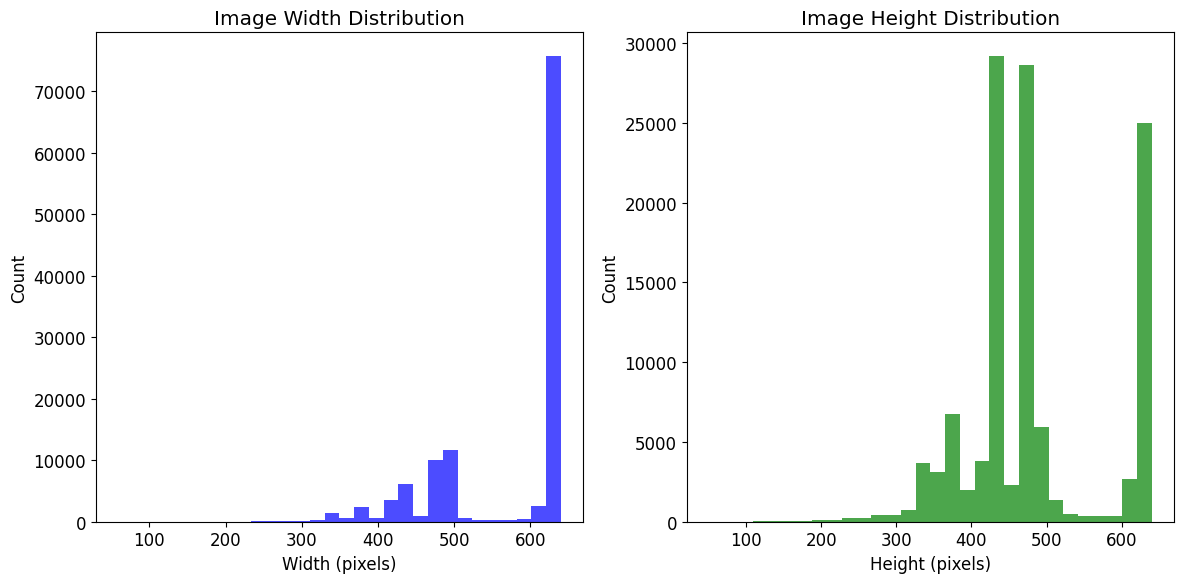

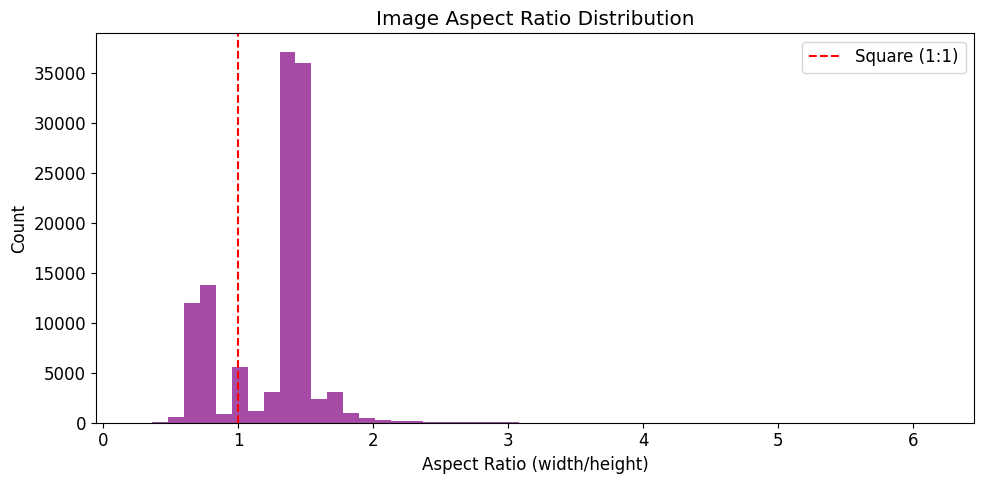

Mean image dimensions: 577.7 x 484.1 pixels
Median image dimensions: 640.0 x 480.0 pixels
Min image dimensions: 59 x 51 pixels
Max image dimensions: 640 x 640 pixels


In [66]:
# Analyze image dimensions
def analyze_image_dimensions(data):
    widths = [img['width'] for img in data['images']]
    heights = [img['height'] for img in data['images']]
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=30, alpha=0.7, color='blue')
    plt.title('Image Width Distribution')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=30, alpha=0.7, color='green')
    plt.title('Image Height Distribution')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Count')
    
    plt.tight_layout()
    plt.show()
    
    # Calculate aspect ratios
    aspect_ratios = [w/h for w, h in zip(widths, heights)]
    
    plt.figure(figsize=(10, 5))
    plt.hist(aspect_ratios, bins=50, alpha=0.7, color='purple')
    plt.title('Image Aspect Ratio Distribution')
    plt.xlabel('Aspect Ratio (width/height)')
    plt.ylabel('Count')
    plt.axvline(x=1.0, color='red', linestyle='--', label='Square (1:1)')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print(f"Mean image dimensions: {np.mean(widths):.1f} x {np.mean(heights):.1f} pixels")
    print(f"Median image dimensions: {np.median(widths):.1f} x {np.median(heights):.1f} pixels")
    print(f"Min image dimensions: {np.min(widths)} x {np.min(heights)} pixels")
    print(f"Max image dimensions: {np.max(widths)} x {np.max(heights)} pixels")

try:
    analyze_image_dimensions(train_data)
except:
    analyze_image_dimensions(train_dataset.coco_data)

C:\Users\dazap\AppData\Local\Temp\ipykernel_19348\3656641363.py:49: RuntimeWarning: divide by zero encountered in divide
  aspect_ratios = widths / heights


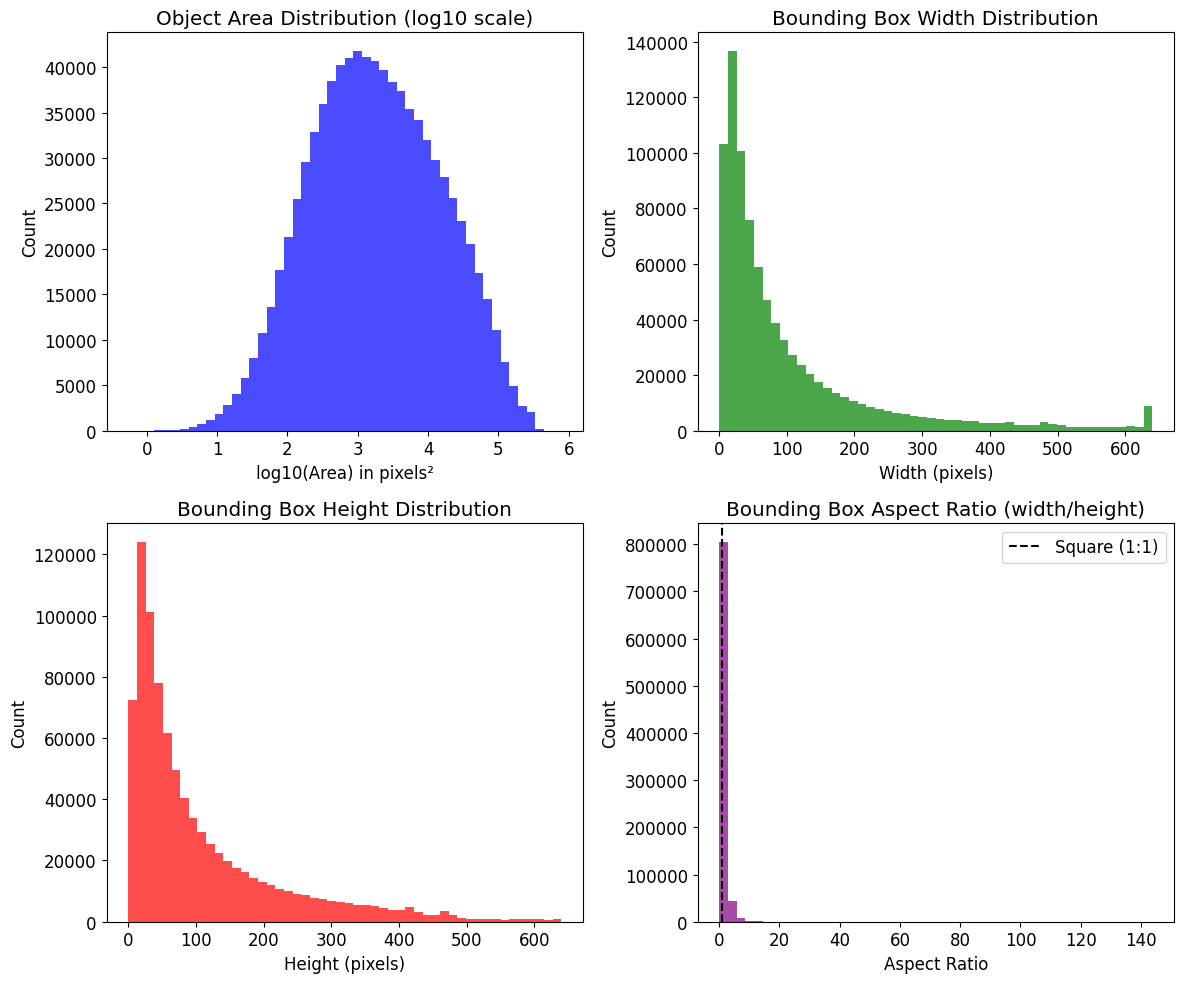

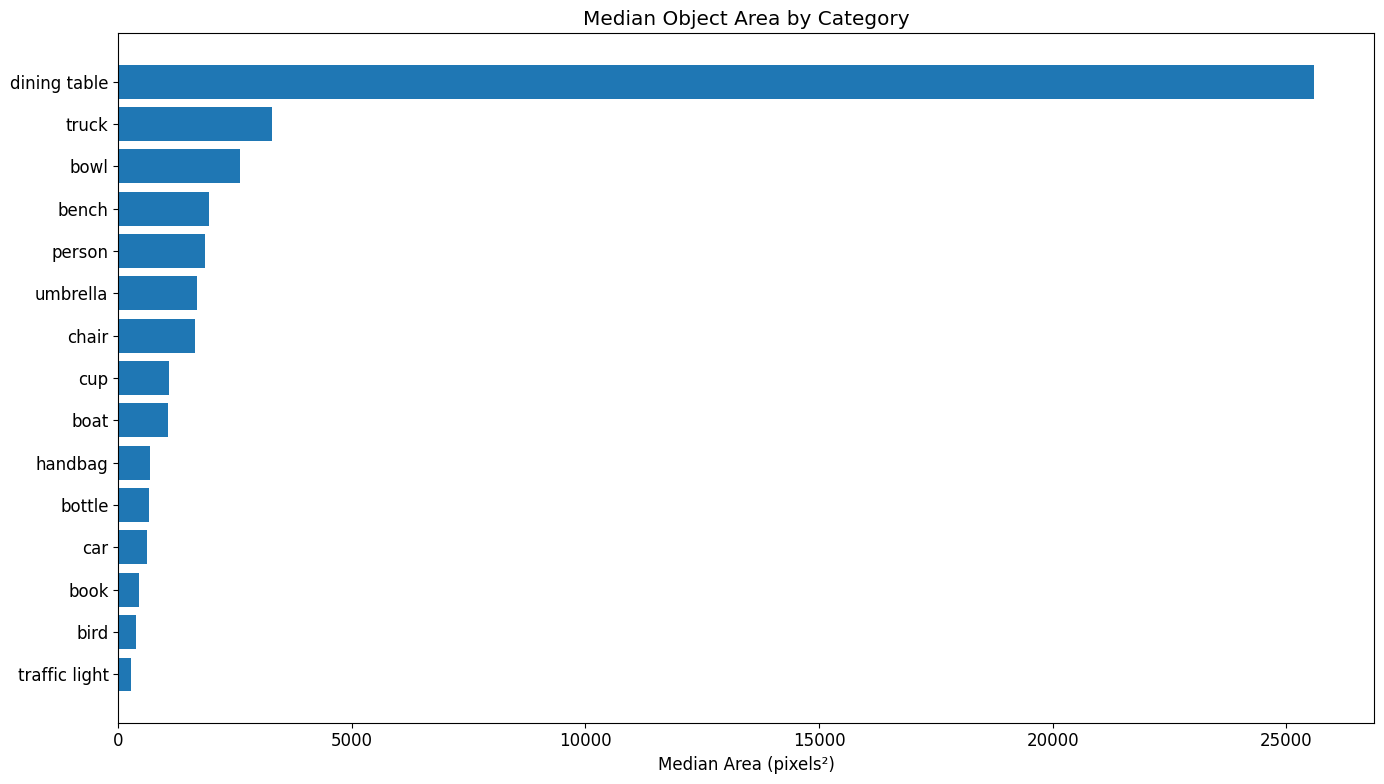

Mean bounding box dimensions: 103.9 x 107.4 pixels
Median bounding box dimensions: 54.1 x 62.3 pixels
Mean object area: 12025.9 pixels²
Median object area: 1697.1 pixels²


In [67]:
# Analyze bounding boxes
def analyze_bounding_boxes(data, categories):
    # Extract bbox information
    bboxes = []
    areas = []
    category_ids = []
    
    for ann in data['annotations']:
        if 'bbox' in ann:
            bboxes.append(ann['bbox'])  # [x, y, width, height]
            areas.append(ann['area'])
            category_ids.append(ann['category_id'])
    
    bboxes = np.array(bboxes)
    areas = np.array(areas)
    
    # Filter out zero or negative areas for log calculation
    valid_areas = areas[areas > 0]
    
    plt.figure(figsize=(12, 10))
    
    plt.subplot(2, 2, 1)
    if len(valid_areas) > 0:
        plt.hist(np.log10(valid_areas), bins=50, alpha=0.7, color='blue')
        plt.title('Object Area Distribution (log10 scale)')
        plt.xlabel('log10(Area) in pixels²')
        plt.ylabel('Count')
    else:
        plt.text(0.5, 0.5, 'No valid areas to display', 
                horizontalalignment='center', verticalalignment='center')
    
    # Box dimensions
    widths = bboxes[:, 2]
    heights = bboxes[:, 3]
    
    plt.subplot(2, 2, 2)
    plt.hist(widths, bins=50, alpha=0.7, color='green')
    plt.title('Bounding Box Width Distribution')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(2, 2, 3)
    plt.hist(heights, bins=50, alpha=0.7, color='red')
    plt.title('Bounding Box Height Distribution')
    plt.xlabel('Height (pixels)')
    plt.ylabel('Count')
    
    plt.subplot(2, 2, 4)
    aspect_ratios = widths / heights
    # Filter out infinite or NaN values
    valid_ratios = aspect_ratios[np.isfinite(aspect_ratios)]
    plt.hist(valid_ratios, bins=50, alpha=0.7, color='purple')
    plt.title('Bounding Box Aspect Ratio (width/height)')
    plt.xlabel('Aspect Ratio')
    plt.ylabel('Count')
    plt.axvline(x=1.0, color='black', linestyle='--', label='Square (1:1)')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    
    # Area by category
    plt.figure(figsize=(14, 8))
    category_names = []
    median_areas = []
    
    # Get top 15 categories by count
    top_categories = Counter(category_ids).most_common(15)
    for cat_id, count in top_categories:
        cat_areas = [area for area, cid in zip(areas, category_ids) if cid == cat_id]
        if cat_areas:
            category_names.append(categories[cat_id])
            median_areas.append(np.median(cat_areas))
    
    # Sort by median area
    sorted_indices = np.argsort(median_areas)
    sorted_names = [category_names[i] for i in sorted_indices]
    sorted_areas = [median_areas[i] for i in sorted_indices]
    
    plt.barh(sorted_names, sorted_areas)
    plt.title('Median Object Area by Category')
    plt.xlabel('Median Area (pixels²)')
    plt.tight_layout()
    plt.show()
    
    print(f"Mean bounding box dimensions: {np.mean(widths):.1f} x {np.mean(heights):.1f} pixels")
    print(f"Median bounding box dimensions: {np.median(widths):.1f} x {np.median(heights):.1f} pixels")
    print(f"Mean object area: {np.mean(areas):.1f} pixels²")
    print(f"Median object area: {np.median(areas):.1f} pixels²")

try:
    categories_dict = {cat['id']: cat['name'] for cat in train_data['categories']}
    analyze_bounding_boxes(train_data, categories_dict)
except:
    categories_dict = {cat_id: info['name'] for cat_id, info in train_dataset.categories.items()}
    analyze_bounding_boxes(train_dataset.coco_data, categories_dict)

Could not visualize samples: 'COCODataset' object has no attribute 'idx_to_cat_id'


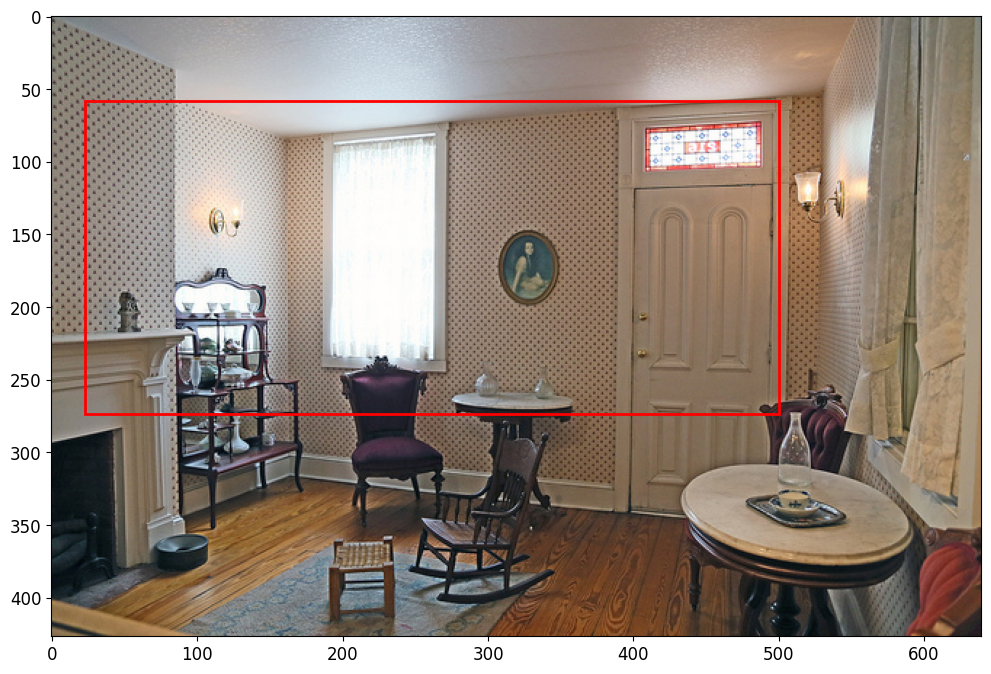

In [68]:
def visualize_samples(dataset, num_samples=5):
    """Visualize random samples from the dataset with annotations"""
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        image, target = dataset[idx]
        
        if isinstance(image, Image.Image):
            image_np = np.array(image)
        else:
            image_np = image.permute(1, 2, 0).numpy()
            
        fig, ax = plt.subplots(1, figsize=(12, 9))
        ax.imshow(image_np)
        
        boxes = target['boxes'].numpy()
        labels = target['labels'].numpy()
        
        # Draw bounding boxes and labels
        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)
            
            category_name = dataset.get_category_name(label.item())
            ax.text(x1, y1-5, category_name, color='r', fontsize=10, 
                   bbox=dict(facecolor='white', alpha=0.7))
        
        ax.set_title(f'Sample {idx}: {len(boxes)} objects')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

try:
    visualize_samples(train_dataset)
except Exception as e:
    print(f"Could not visualize samples: {e}")

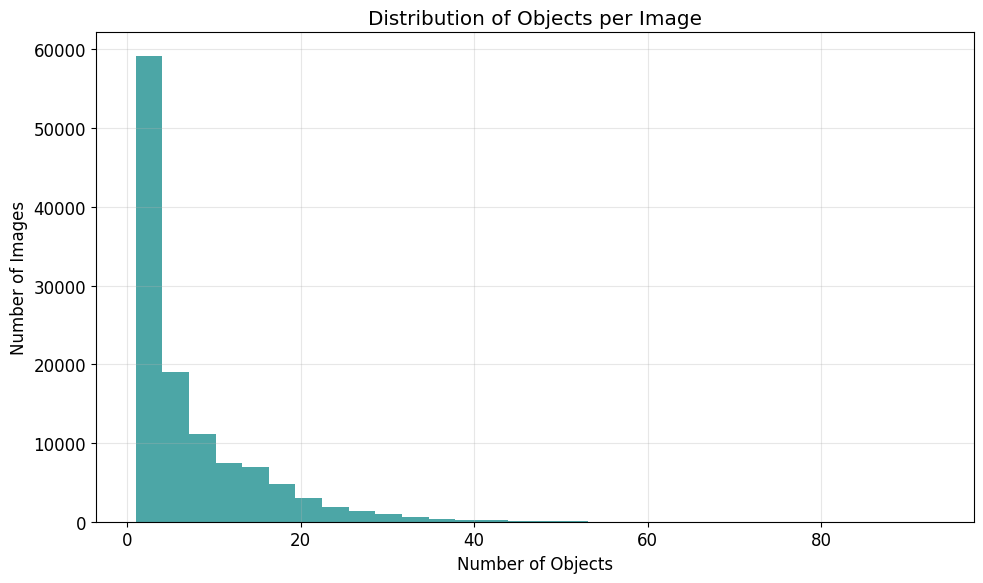

Mean objects per image (non-empty only): 7.33
Median objects per image (non-empty only): 4.00
Maximum objects in one image: 93
Images with no objects: 1021


In [69]:
# Analyze the distribution of objects per image
def analyze_objects_per_image(data):
    img_ids_all = {img['id'] for img in data['images']}
    objects_per_image = Counter()
    for ann in data['annotations']:
        objects_per_image[ann['image_id']] += 1

    covered = set(objects_per_image.keys())
    zero_objs = len(img_ids_all - covered)

    counts = list(objects_per_image.values())
    plt.figure(figsize=(10, 6))
    plt.hist(counts, bins=30, color='teal', alpha=0.7)
    plt.title('Distribution of Objects per Image')
    plt.xlabel('Number of Objects')
    plt.ylabel('Number of Images')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Mean objects per image (non-empty only): {np.mean(counts):.2f}")
    print(f"Median objects per image (non-empty only): {np.median(counts):.2f}")
    print(f"Maximum objects in one image: {np.max(counts) if counts else 0}")
    print(f"Images with no objects: {zero_objs}")


try:
    analyze_objects_per_image(train_data)
except:
    analyze_objects_per_image(train_dataset.coco_data)

In [70]:
import numpy as np
import torch
from pycocotools import mask as maskUtils

# COCO bbox: [x, y, w, h] → clip у межі зображення
def clip_xywh_to_image(bboxes, H, W):
    b = bboxes.copy()
    b[:, 0] = np.clip(b[:, 0], 0, W-1)
    b[:, 1] = np.clip(b[:, 1], 0, H-1)
    b[:, 2] = np.clip(b[:, 2], 1e-6, W - b[:, 0])  # w
    b[:, 3] = np.clip(b[:, 3], 1e-6, H - b[:, 1])  # h
    return b

# Відсіяти дрібні коробки за площею/мін. розміром сторін
def filter_small_boxes_xywh(bboxes, labels, areas=None, min_area=16.0, min_side=2.0):
    w = bboxes[:, 2]; h = bboxes[:, 3]
    keep = (w >= min_side) & (h >= min_side) & ((w*h) >= min_area)
    b = bboxes[keep]
    l = labels[keep]
    a = areas[keep] if areas is not None else None
    return b, l, a, keep

# COCO segmentation (polygons/RLE) → маски [N, H, W] (uint8)
def decode_segmentations_to_masks(segmentations, H, W):
    masks = []
    for seg in segmentations:
        if isinstance(seg, list):                      # polygons
            rles = maskUtils.frPyObjects(seg, H, W)
            rle = maskUtils.merge(rles)
        elif isinstance(seg, dict) and 'counts' in seg:  # RLE
            rle = seg
        else:
            continue
        m = maskUtils.decode(rle)  # [H,W] {0,1}
        masks.append(m.astype(np.uint8))
    if len(masks) == 0:
        return np.zeros((0, H, W), dtype=np.uint8)
    return np.stack(masks, axis=0)


In [71]:

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
try:
    from turbojpeg import TurboJPEG  # pip install pyTurboJPEG
    _jpeg = TurboJPEG()
    USE_TURBOJPEG = True
except Exception:
    USE_TURBOJPEG = False
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def build_train_transform(img_max=1024, stride=32, min_area=16.0, min_visibility=0.0):
    return A.Compose([
        A.LongestMaxSize(max_size=img_max, interpolation=cv2.INTER_LINEAR),

        # ВАЖЛИВО: явно прибираємо min_* і задаємо тільки divisors
        A.PadIfNeeded(
            min_height=None, min_width=None,
            pad_height_divisor=stride, pad_width_divisor=stride,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(114,114,114), fill_mask=0
        ),

        A.Affine(
            scale=(0.85, 1.15),
            translate_percent=(-0.05, 0.05),
            rotate=(-10, 10),
            shear=(-5, 5),
            border_mode=cv2.BORDER_CONSTANT,
            fill=(114,114,114),
            p=0.5
        ),

        A.RandomBrightnessContrast(p=0.30),
        A.ColorJitter(p=0.20),
        A.GaussianBlur(blur_limit=(3,5), p=0.15),

        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='coco', label_fields=['labels', 'iscrowd'],
        min_area=min_area, min_visibility=min_visibility
    ),
    strict=True)

def build_val_transform(img_max=1024, stride=32):
    return A.Compose([
        A.LongestMaxSize(max_size=img_max, interpolation=cv2.INTER_LINEAR),
        A.PadIfNeeded(
            min_height=None, min_width=None,
            pad_height_divisor=stride, pad_width_divisor=stride,
            border_mode=cv2.BORDER_CONSTANT,
            fill=(114,114,114), fill_mask=0
        ),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ],
    bbox_params=A.BboxParams(
        format='coco', label_fields=['labels', 'iscrowd'],
        min_area=0.0, min_visibility=0.0
    ),
    strict=True)
def fast_imread_rgb(path):
    if USE_TURBOJPEG and path.lower().endswith((".jpg", ".jpeg")):
        with open(path, "rb") as f:
            img = _jpeg.decode(f.read(), pixel_format=TurboJPEG.TJPF_RGB)  # HWC RGB uint8
        return img
    # OpenCV (BGR) -> RGB
    img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR)  # швидше за cv2.imread на Windows
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [84]:
import random
from PIL import Image

class COCODatasetWithTransforms(COCODataset):
    def __init__(self, root_dir, annotation_file, transform=None, return_masks=True,
                 min_area_post=16.0, min_side_post=2.0,
                 multiscale_choices=None, stride=32):
        super().__init__(root_dir, annotation_file, transform=None)
        self.return_masks = return_masks
        self.min_area_post = min_area_post
        self.min_side_post = min_side_post
        self.stride = stride

        # COCO ids -> 1..K
        self.cat_ids = sorted(list(self.categories.keys()))
        self.cat_id_to_idx = {cid: i+1 for i, cid in enumerate(self.cat_ids)}
        self.idx_to_cat_id = {i+1: cid for i, cid in enumerate(self.cat_ids)}

        # --- multi-scale пул для TRAIN або одиночний transform для VAL ---
        if multiscale_choices is None:
            self.albu_pool = None
            self.albu = transform  # валідний пайплайн (evaluation)
        else:
            # якщо є CFG — беремо його мінпороги, інакше дефолти
            try:
                MIN_AREA, MIN_VIS = CFG.min_area, CFG.min_visibility
            except NameError:
                MIN_AREA, MIN_VIS = 16.0, 0.0
            self.albu_pool = {
                s: build_train_transform(img_max=s, stride=self.stride,
                                         min_area=MIN_AREA, min_visibility=MIN_VIS)
                for s in multiscale_choices
            }
            self.albu = None  # у train обиратимемо з пулу

    def _choose_transform(self):
        return random.choice(list(self.albu_pool.values()))

    def get_category_name(self, label_idx: int) -> str:
        coco_id = self.idx_to_cat_id[int(label_idx)]
        return self.categories[coco_id]['name']

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_info = self.images[image_id]
        file_name = img_info['file_name']
        img_path = os.path.join(self.root_dir, file_name)
        image = fast_imread_rgb(img_path)
        H, W = image.shape[:2]

        anns = self.image_annotations[image_id]
        boxes, labels, areas, segmentations, iscrowd = [], [], [], [], []
        for ann in anns:
            if 'bbox' in ann:
                boxes.append(ann['bbox'])  # COCO xywh
                labels.append(ann['category_id'])
                areas.append(ann.get('area', ann['bbox'][2] * ann['bbox'][3]))
                segmentations.append(ann.get('segmentation', None))
                iscrowd.append(ann.get('iscrowd', 0))

        boxes   = np.array(boxes,  dtype=np.float32) if boxes   else np.zeros((0,4), np.float32)
        labels  = np.array(labels, dtype=np.int64)   if labels  else np.zeros((0,),  np.int64)
        areas   = np.array(areas,  dtype=np.float32) if areas   else np.zeros((0,),  np.float32)
        iscrowd = np.array(iscrowd,dtype=np.int64)   if iscrowd else np.zeros((0,),  np.int64)

        if len(labels):
            labels = np.array([self.cat_id_to_idx[int(c)] for c in labels], dtype=np.int64)

        masks = []
        if self.return_masks and len(segmentations) > 0:
            masks = decode_segmentations_to_masks(segmentations, H, W)
            masks = [m for m in masks]

        if len(boxes):
            boxes = clip_xywh_to_image(boxes, H, W)

        # вибір трансформу: або з пулу (train), або одиночний (val)
        apply_tf = self._choose_transform() if self.albu_pool is not None else self.albu

        if apply_tf is not None:
            transformed = apply_tf(
                image=image,
                bboxes=boxes.tolist(),
                labels=labels.tolist(),
                masks=masks if len(masks) else None,
                iscrowd=iscrowd.tolist()
            )
            image  = transformed['image']  # Tensor [C,H,W]
            tb     = np.array(transformed['bboxes'], dtype=np.float32)   # xywh
            tl     = np.array(transformed['labels'], dtype=np.int64)     # 1..K
            tcrowd = np.array(transformed.get('iscrowd', []), dtype=np.int64)
            tm     = transformed.get('masks', None)

            if len(tb):
                tb, tl, _, keep_wh = filter_small_boxes_xywh(tb, tl, None,
                                                             min_area=self.min_area_post,
                                                             min_side=self.min_side_post)
                if tm is not None and len(tm):
                    tm = [tm[i] for i, k in enumerate(keep_wh) if k]
                if tcrowd.size:
                    tcrowd = tcrowd[keep_wh]

            Ht, Wt = int(image.shape[1]), int(image.shape[2])
            boxes_xyxy = coco_xywh_to_xyxy(tb)
            boxes_xyxy = clip_xyxy_to_image(boxes_xyxy, Ht, Wt)

            boxes_xyxy, tl, tcrowd, tm, keep_final = sanitize_xyxy(
                boxes_xyxy, tl, tcrowd, tm, min_w=1.0, min_h=1.0
            )

            boxes  = boxes_xyxy
            labels = tl
            areas  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

            if tm is not None:
                if len(tm):
                    masks = torch.stack([torch.as_tensor(m, dtype=torch.uint8) for m in tm], dim=0)
                else:
                    masks = torch.zeros((0, Ht, Wt), dtype=torch.uint8)
            iscrowd = tcrowd if tcrowd.size else np.zeros((0,), dtype=np.int64)

        else:
            boxes = coco_xywh_to_xyxy(boxes)
            boxes = clip_xyxy_to_image(boxes, H, W)
            boxes, labels, iscrowd, masks, _ = sanitize_xyxy(boxes, labels, iscrowd, masks, min_w=1.0, min_h=1.0)
            areas  = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
            image  = torch.from_numpy(image).permute(2,0,1).float()/255.0
            if self.return_masks and isinstance(masks, list) and len(masks):
                masks = torch.stack([torch.as_tensor(m, dtype=torch.uint8) for m in masks], dim=0)

        target = {
            'boxes':   torch.as_tensor(boxes,  dtype=torch.float32),  # XYXY
            'labels':  torch.as_tensor(labels, dtype=torch.int64),    # 1..K
            'image_id':torch.tensor([image_id], dtype=torch.int64),
            'area':    torch.as_tensor(areas if len(labels) else np.zeros((0,), np.float32)),
            'iscrowd': torch.as_tensor(iscrowd if len(labels) else np.zeros((0,), np.int64)),
        }
        if self.return_masks:
            if isinstance(masks, np.ndarray):
                masks = torch.from_numpy(masks.astype(np.uint8))
            if masks is None:
                Ht, Wt = int(image.shape[1]), int(image.shape[2])
                masks = torch.zeros((0, Ht, Wt), dtype=torch.uint8)
            target['masks'] = masks

        return image, target


In [ ]:
# === DATASETS & DATALOADERS (multi-scale + deterministic) ===
import random
from dataclasses import dataclass
import torch
from torch.utils.data import DataLoader

# 0) Config (створюємо, якщо ще нема; або доповнюємо існуючий)
if 'CFG' not in globals():
    @dataclass
    class TrainConfig:
        img_max_choices: tuple = (896, 1024, 1152, 1280)  # довга сторона для multi-scale train
        min_area: float = 16.0
        min_visibility: float = 0.0
        seed: int = 42
    CFG = TrainConfig()
else:
    # гарантуємо потрібні поля
    CFG.img_max_choices = getattr(CFG, 'img_max_choices', (896, 1024, 1152, 1280))
    CFG.min_area        = getattr(CFG, 'min_area', 16.0)
    CFG.min_visibility  = getattr(CFG, 'min_visibility', 0.0)
    CFG.seed            = getattr(CFG, 'seed', 42)

# 1) Collate (створюємо, якщо ще нема)
if 'detection_collate' not in globals():
    def detection_collate(batch):
        images, targets = list(zip(*batch))
        return images, targets  # списки тензорів/словників — стандартно для torchvision моделей

# 2) Фіксація сиду (детермінізм)
def seed_everything(seed: int = 42):
    import os, numpy as np, random, torch
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        import albumentations as A
        if hasattr(A, "set_seed"):
            A.set_seed(seed)
    except Exception:
        pass
    return seed

SEED = seed_everything(CFG.seed)

def worker_init_fn(worker_id):
    import numpy as np, random
    s = SEED + worker_id
    np.random.seed(s); random.seed(s)

g = torch.Generator()
g.manual_seed(SEED)

# 3) Datasets
# TRAIN: multi-scale через пул трансформів (обирається випадковий img_max на кожен сэмпл)
train_ds = COCODatasetWithTransforms(
    TRAIN_ROOT, TRAIN_ANNOTATION,
    multiscale_choices=CFG.img_max_choices,  # головне — вмикає multi-scale
    stride=32,
    return_masks=True
)

# VAL: один фіксований валідний трансформ
val_tf = build_val_transform(img_max=1024, stride=32)
val_ds = COCODatasetWithTransforms(
    VAL_ROOT, VAL_ANNOTATION,
    transform=val_tf,
    return_masks=True
)

# 4) DataLoaders
BATCH_SIZE = 4
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate,
    pin_memory=True,
    drop_last=True,
    worker_init_fn=worker_init_fn,
    generator=g,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate,
    pin_memory=True,
    worker_init_fn=worker_init_fn,
    generator=g,
)

# 5) Швидкий sanity-check
img, tgt = train_ds[0]
print("Train sample image shape:", tuple(img.shape), "(C,H,W)")
print("Targets keys:", list(tgt.keys()))


In [86]:
def coco_xywh_to_xyxy(boxes: np.ndarray) -> np.ndarray:
    if boxes.size == 0:
        return boxes.reshape(0, 4)
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = x1 + boxes[:, 2]
    y2 = y1 + boxes[:, 3]
    return np.stack([x1, y1, x2, y2], axis=1)

def clip_xyxy_to_image(boxes: np.ndarray, H: int, W: int) -> np.ndarray:
    if boxes.size == 0:
        return boxes.reshape(0, 4)
    b = boxes.copy()
    b[:, 0] = np.clip(b[:, 0], 0, W - 1)
    b[:, 1] = np.clip(b[:, 1], 0, H - 1)
    b[:, 2] = np.clip(b[:, 2], 0, W - 1)
    b[:, 3] = np.clip(b[:, 3], 0, H - 1)
    # гарантуємо додатну ширину/висоту
    b[:, 2] = np.maximum(b[:, 2], b[:, 0] + 1e-6)
    b[:, 3] = np.maximum(b[:, 3], b[:, 1] + 1e-6)
    return b
def sanitize_xyxy(boxes_xyxy: np.ndarray,
                  labels: np.ndarray,
                  iscrowd: np.ndarray | None = None,
                  masks: list | None = None,
                  min_w: float = 1.0,
                  min_h: float = 1.0):
    """Фінальна чистка: прибрати бокси з (w<hmin або h<min_h), синхронізувати labels/iscrowd/masks."""
    if boxes_xyxy.size == 0:
        return boxes_xyxy.reshape(0,4), labels[:0], (iscrowd[:0] if iscrowd is not None else np.zeros((0,), np.int64)), [], np.array([], dtype=bool)

    w = boxes_xyxy[:, 2] - boxes_xyxy[:, 0]
    h = boxes_xyxy[:, 3] - boxes_xyxy[:, 1]
    keep = (w >= min_w) & (h >= min_h)

    boxes_xyxy = boxes_xyxy[keep]
    labels = labels[keep] if labels is not None and len(labels) else labels
    if iscrowd is not None and len(iscrowd):
        iscrowd = iscrowd[keep]
    else:
        iscrowd = np.zeros((len(boxes_xyxy),), dtype=np.int64)

    if masks is not None and len(masks):
        masks = [m for i, m in enumerate(masks) if keep[i]]
    else:
        masks = []

    return boxes_xyxy, labels, iscrowd, masks, keep


In [87]:
img, tgt = train_ds[0]
b = tgt['boxes'].numpy()
assert b.shape[-1] == 4 and (b[:, 2] > b[:, 0]).all() and (b[:, 3] > b[:, 1]).all(), "Boxes must be XYXY with positive size"
assert (b[:, 0] >= 0).all() and (b[:, 1] >= 0).all() and (b[:, 2] <= img.shape[2]).all() and (b[:, 3] <= img.shape[1]).all(), "Boxes must be clipped to image"
print("OK: XYXY, clipped, positive area.")


OK: XYXY, clipped, positive area.


In [88]:
# === Aspect-Ratio Buckets ===
from collections import defaultdict
from torch.utils.data import Sampler, DataLoader

def build_aspect_buckets(dataset, bins=(0.75, 1.33)):
    """
    bins: межі для H/W (наприклад, <0.75 — «широкі», 0.75..1.33 — ~квадратні, >1.33 — «високі»).
    """
    buckets = defaultdict(list)
    for idx, img_id in enumerate(dataset.image_ids):
        info = dataset.images[img_id]
        H, W = info['height'], info['width']
        ar = H / max(W, 1)
        b = 0 if ar > bins[1] else (2 if ar < bins[0] else 1)
        buckets[b].append(idx)
    return buckets

class AspectBucketBatchSampler(Sampler[list]):
    def __init__(self, buckets: dict, batch_size: int, shuffle: bool = True, seed: int = 42):
        self.buckets = {k: v[:] for k, v in buckets.items()}
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.seed = seed

    def __iter__(self):
        rng = random.Random(self.seed)
        # робимо локальні копії списків
        local = {k: v[:] for k, v in self.buckets.items()}
        while True:
            made_any = False
            for k, idxs in local.items():
                if self.shuffle:
                    rng.shuffle(idxs)
                while len(idxs) >= self.batch_size:
                    batch = idxs[:self.batch_size]
                    del idxs[:self.batch_size]
                    made_any = True
                    yield batch
            if not made_any:
                break

    def __len__(self):
        return sum(len(v) // self.batch_size for v in self.buckets.values())
